# Customer Segmentation using K-Means Clustering

This notebook performs customer segmentation using the K-Means clustering algorithm on the Mall Customer Segmentation dataset.

**Steps covered:**
1. Load & explore the dataset
2. Preprocess and normalize features
3. Determine optimal K using the Elbow Method
4. Apply K-Means Clustering
5. Visualize clusters
6. Analyze & interpret segments

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

> **Dataset**: [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)  
> Download `sales_data.csv` from Kaggle and place it in the same directory as this notebook.  
> Alternatively, the cell below generates synthetic data with similar structure so you can run the notebook immediately.

In [2]:
import os

if os.path.exists('sales_data.csv'):
    df = pd.read_csv('sales_data.csv')
    print('Loaded real dataset.')
else:
    print('sales_data.csv not found — generating synthetic data...')
    np.random.seed(42)
    n = 200

    # Four clusters: (age, income, spend_score)
    segments = [
        dict(age=(22, 5), income=(25, 8),  score=(75, 12), n=50),   # Young budget-high-spend
        dict(age=(35, 7), income=(80, 15), score=(80, 10), n=50),   # Premium active
        dict(age=(45, 8), income=(55, 12), score=(50, 10), n=50),   # Mature steady
        dict(age=(60, 7), income=(30, 10), score=(25, 10), n=50),   # Senior cautious
    ]

    rows = []
    for i, s in enumerate(segments):
        for j in range(s['n']):
            rows.append({
                'CustomerID': len(rows) + 1,
                'Gender': np.random.choice(['Male', 'Female']),
                'Age': int(np.clip(np.random.normal(*s['age']), 18, 75)),
                'Annual Income (k$)': int(np.clip(np.random.normal(*s['income']), 10, 140)),
                'Spending Score (1-100)': int(np.clip(np.random.normal(*s['score']), 1, 100)),
            })

    df = pd.DataFrame(rows)
    print('Synthetic dataset created.')

print(f'Shape: {df.shape}')
df.head(10)

Mall_Customers.csv not found — generating synthetic data...
Synthetic dataset created.
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,29,80
1,2,Female,28,27,87
2,3,Female,19,26,77
3,4,Female,22,21,69
4,5,Female,22,21,68
5,6,Female,21,19,49
6,7,Male,18,36,74
7,8,Male,23,15,79
8,9,Male,18,33,84
9,10,Female,18,20,74


## 3. Exploratory Data Analysis

In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Summary Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== Summary Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.00000
mean,100.500000,40.480000,47.880000,58.19500
std,57.879185,15.780199,26.822056,25.83144
min,1.000000,18.000000,10.000000,1.00000
25%,50.750000,26.000000,25.000000,41.25000
50%,100.500000,39.000000,40.500000,63.00000
75%,150.250000,54.000000,70.250000,79.00000
max,200.000000,75.000000,125.000000,100.00000


In [4]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


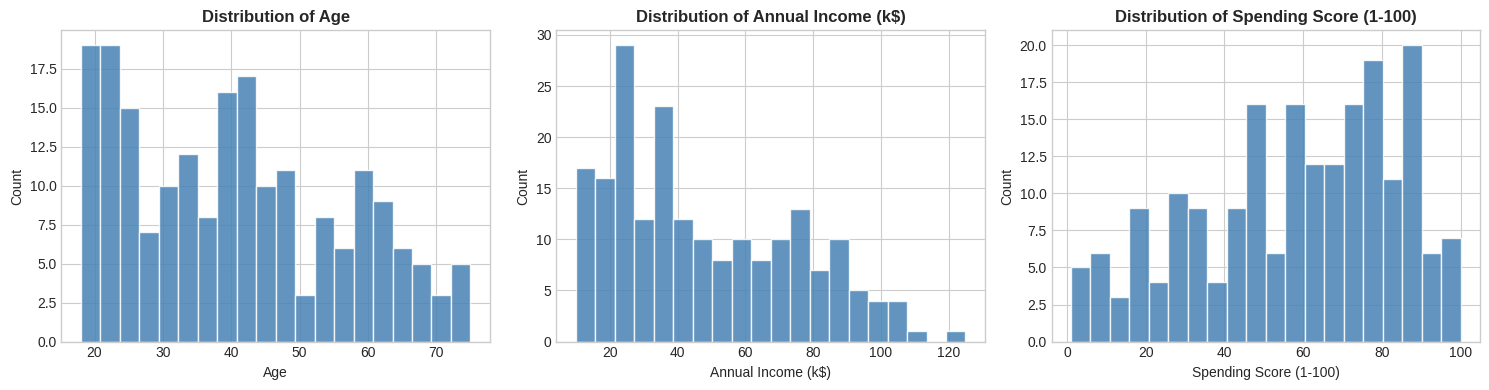

Saved: eda_distributions.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, feat in zip(axes, features):
    ax.hist(df[feat], bins=20, edgecolor='white', color='steelblue', alpha=0.85)
    ax.set_title(f'Distribution of {feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_distributions.png')

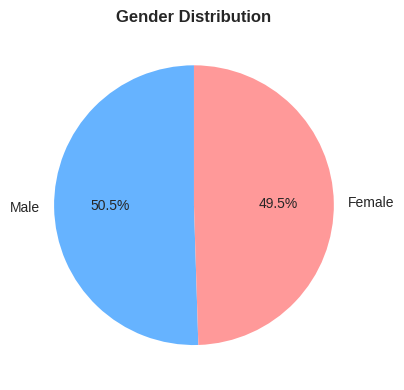

In [6]:
# Gender distribution
gender_counts = df['Gender'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['#66b3ff', '#ff9999'], startangle=90)
ax.set_title('Gender Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_gender.png', dpi=150, bbox_inches='tight')
plt.show()

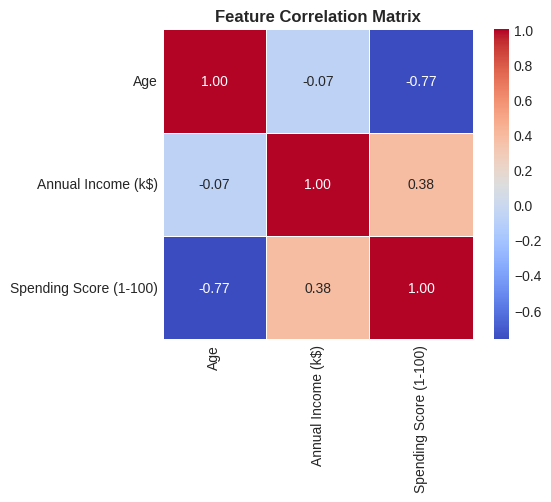

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing

In [8]:
# Select features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature means after scaling (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Feature stds  after scaling (should be ~1):', X_scaled.std(axis=0).round(4))

Feature means after scaling (should be ~0): [ 0. -0. -0.]
Feature stds  after scaling (should be ~1): [1. 1. 1.]


## 5. Determine Optimal K — Elbow Method + Silhouette Score

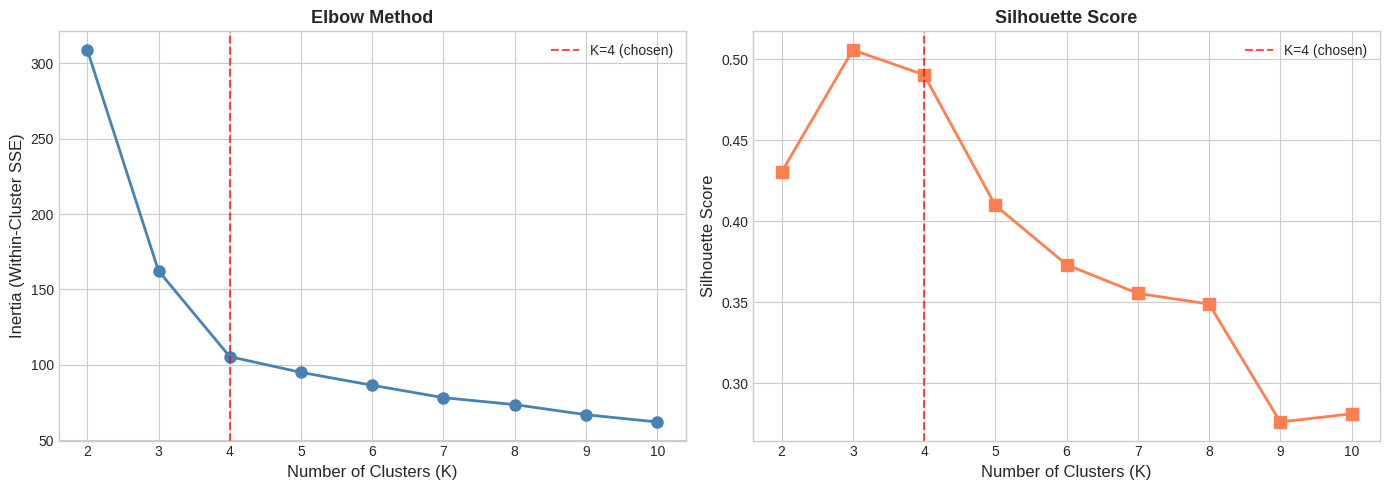

Saved: optimal_k.png


In [9]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster SSE)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (chosen)')
axes[0].legend()

# Silhouette scores
axes[1].plot(list(k_range), silhouettes, 's-', color='coral', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (chosen)')
axes[1].legend()

plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimal_k.png')

## 6. Apply K-Means with K=4

In [10]:
K = 4
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, max_iter=300, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
print(f'K-Means Inertia      : {kmeans.inertia_:.2f}')
print(f'Silhouette Score     : {sil:.4f}')
print(f'\nCluster distribution :')
print(df['Cluster'].value_counts().sort_index())

K-Means Inertia      : 105.47
Silhouette Score     : 0.4905

Cluster distribution :
Cluster
0    50
1    50
2    49
3    51
Name: count, dtype: int64


## 7. Visualize Clusters

In [11]:
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
cluster_names = {}

# Auto-name clusters based on mean age and spend
stats = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
for c in range(K):
    age = stats.loc[c, 'Age']
    inc = stats.loc[c, 'Annual Income (k$)']
    spd = stats.loc[c, 'Spending Score (1-100)']
    if age < 35 and spd > 60:
        cluster_names[c] = 'Young High-Spenders'
    elif inc > 65 and spd > 65:
        cluster_names[c] = 'Premium Active'
    elif age > 50 and spd < 40:
        cluster_names[c] = 'Senior Cautious'
    else:
        cluster_names[c] = 'Mature Steady'

df['Segment'] = df['Cluster'].map(cluster_names)
print('Segment mapping:', cluster_names)

Segment mapping: {0: 'Young High-Spenders', 1: 'Senior Cautious', 2: 'Young High-Spenders', 3: 'Mature Steady'}


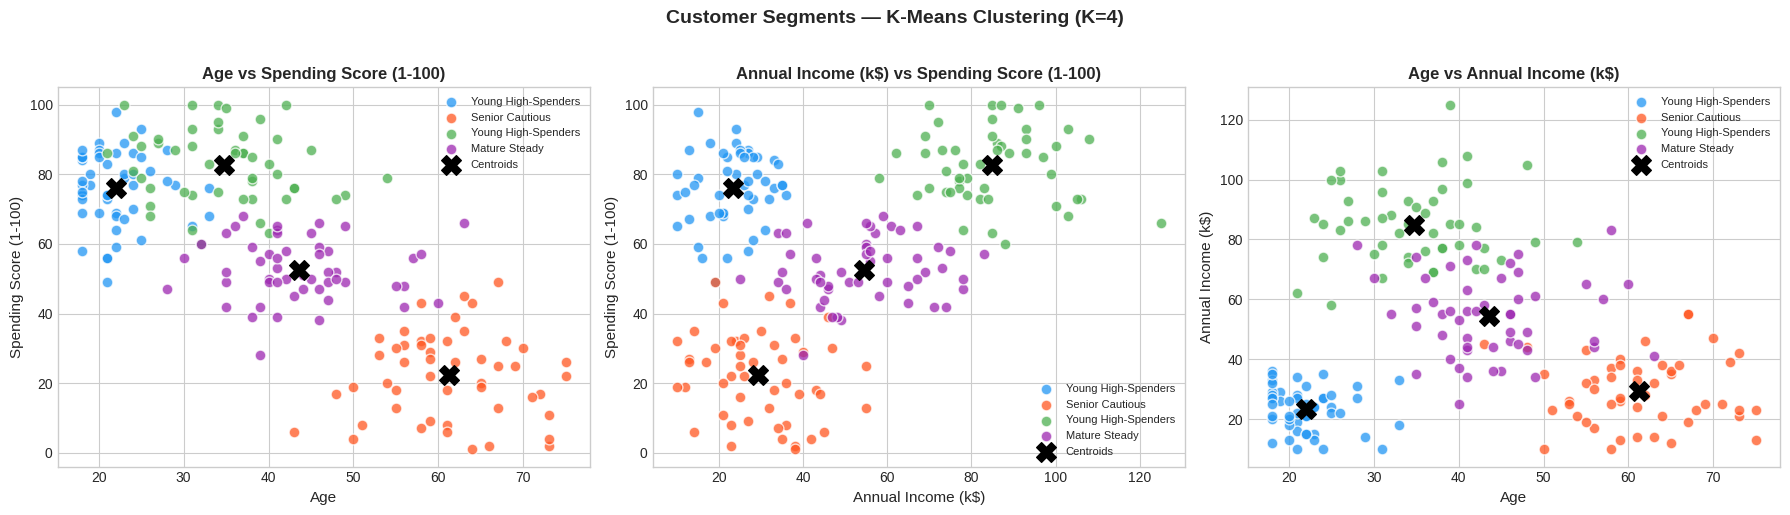

Saved: clusters_scatter.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ('Age', 'Spending Score (1-100)'),
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Annual Income (k$)'),
]

for ax, (x_feat, y_feat) in zip(axes, pairs):
    for c in range(K):
        mask = df['Cluster'] == c
        ax.scatter(
            df.loc[mask, x_feat], df.loc[mask, y_feat],
            c=colors[c], label=cluster_names[c], alpha=0.75, edgecolors='white', s=60
        )
    # Plot centroids (inverse transform)
    centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
    xi = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'].index(x_feat)
    yi = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'].index(y_feat)
    ax.scatter(centroids_orig[:, xi], centroids_orig[:, yi],
               c='black', marker='X', s=200, zorder=5, label='Centroids')
    ax.set_xlabel(x_feat, fontsize=11)
    ax.set_ylabel(y_feat, fontsize=11)
    ax.set_title(f'{x_feat} vs {y_feat}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Customer Segments — K-Means Clustering (K=4)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: clusters_scatter.png')

## 8. Segment Analysis

In [13]:
summary = df.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_SpendScore=('Spending Score (1-100)', 'mean'),
).round(1)

print('=== Segment Summary ===')
print(summary.to_string())

=== Segment Summary ===
                     Count  Avg_Age  Avg_Income  Avg_SpendScore
Segment                                                        
Mature Steady           51     43.6        54.5            52.5
Senior Cautious         50     61.3        29.4            22.3
Young High-Spenders     99     28.3        53.8            79.2


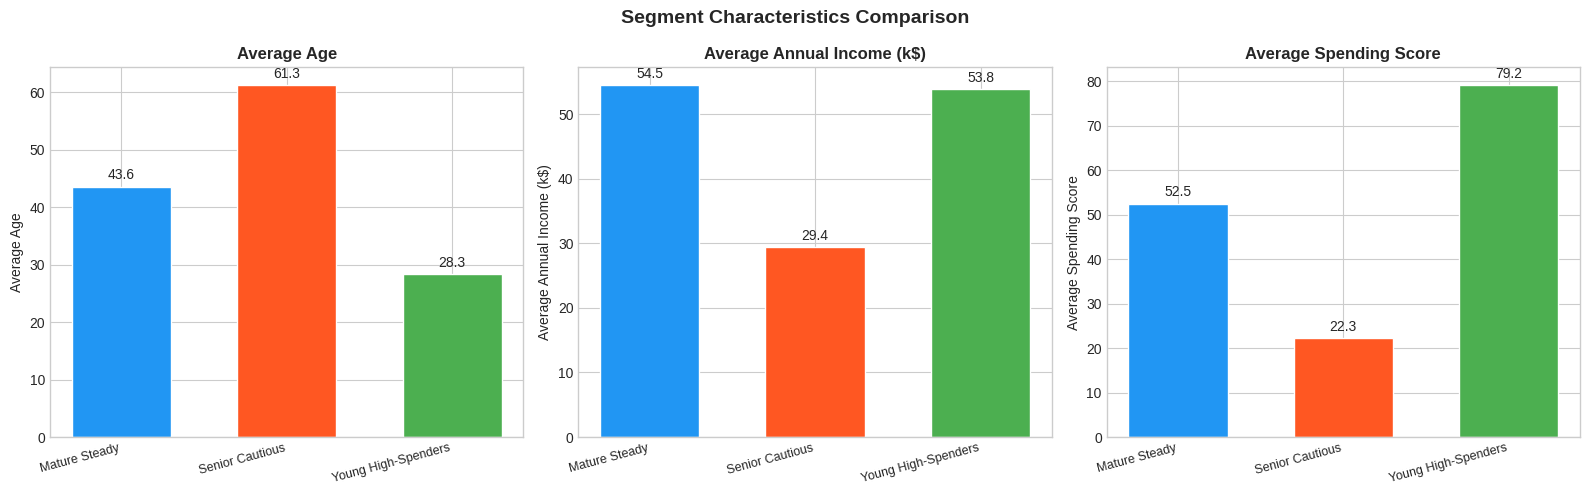

Saved: segment_analysis.png


In [14]:
# Bar charts for each metric per segment
metrics = ['Avg_Age', 'Avg_Income', 'Avg_SpendScore']
titles  = ['Average Age', 'Average Annual Income (k$)', 'Average Spending Score']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seg_colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0'][:len(summary)]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(summary.index, summary[metric], color=seg_colors, edgecolor='white', width=0.6)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticklabels(summary.index, rotation=15, ha='right', fontsize=9)

plt.suptitle('Segment Characteristics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: segment_analysis.png')

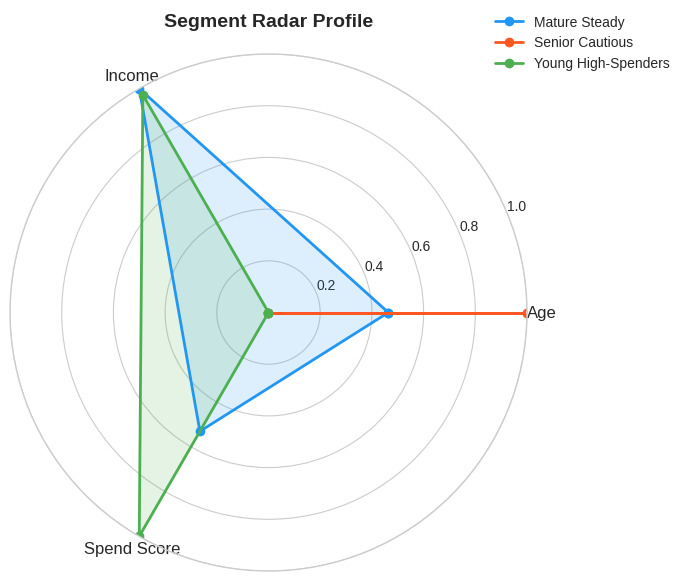

Saved: radar_profile.png


In [15]:
# Radar chart for segment profiles
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize metrics 0-1 for radar
norm = summary[metrics].copy()
for col in metrics:
    norm[col] = (norm[col] - norm[col].min()) / (norm[col].max() - norm[col].min() + 1e-9)

labels = ['Age', 'Income', 'Spend Score']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (seg, row), color in zip(norm.iterrows(), seg_colors):
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=seg, color=color)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
ax.set_title('Segment Radar Profile', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('radar_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: radar_profile.png')

## 9. Export Results

In [16]:
df.to_csv('customer_segments_output.csv', index=False)
print('Exported: customer_segments_output.csv')
print(f'\nFinal dataset shape: {df.shape}')
print(df[['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']].head(10))

Exported: customer_segments_output.csv

Final dataset shape: (200, 7)
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0           1   19                  29                      80        0   
1           2   28                  27                      87        0   
2           3   19                  26                      77        0   
3           4   22                  21                      69        0   
4           5   22                  21                      68        0   
5           6   21                  19                      49        0   
6           7   18                  36                      74        0   
7           8   23                  15                      79        0   
8           9   18                  33                      84        0   
9          10   18                  20                      74        0   

               Segment  
0  Young High-Spenders  
1  Young High-Spenders  
2  Young High-Spenders  
3  Y

## 10. Summary & Business Insights

| Segment | Key Traits | Recommended Strategy |
|---|---|---|
| **Young High-Spenders** | Young age, high spend score | Loyalty rewards, trendy products, social campaigns |
| **Premium Active** | High income, high spend | Exclusive memberships, premium upsells, VIP treatment |
| **Mature Steady** | Mid income, moderate spend | Value bundles, relationship marketing, quality messaging |
| **Senior Cautious** | Older, low spend | Discounts, trust-building, simplified UX, customer support |

**Model Performance:**
- Algorithm: K-Means++ (K=4)
- Optimal K determined via Elbow Method + Silhouette Score
- Features normalized with `StandardScaler` before clustering